In [67]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sci
import statsmodels.tsa.stattools as sm
from scipy.optimize import brentq
%matplotlib inline

In [68]:
S = 100
K = 100
T = 1
μ = r = 0.05
ν0 = 0.04
Θ = 0.04
κ = 2.0
ξ = 0.5
ρ = 0.7
N = 252
n_sims = 100000
dt = T / N

K_min = 80
K_max = 150

### Code

In [69]:
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)


def call_price(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))*S - sci.norm.cdf(d2(S, K, T, r, sigma))*K*np.exp(-r*T)

In [70]:
def dSt(μ, St, dt, ν_t, dWs):
    return μ * St * dt + np.sqrt(ν_t) * St * dWs

In [71]:
def dν_t(κ, Θ, ν_t, dt, ξ, dWν):
    return κ * (Θ - ν_t) * dt + ξ * np.sqrt(ν_t) * dWν 

In [72]:
def correlated_noise(n_sims, N, ρ, dt):
    z1 = np.random.randn(n_sims, N)
    z2 = np.random.randn(n_sims, N)
    dWs = np.sqrt(dt) * z1
    dWν = np.sqrt(dt) * (ρ * z1 + np.sqrt(1 - ρ **2) * z2)
    return dWs, dWν 

In [73]:
def gen_νs(κ, Θ, ν_t, dt, ξ, dWν, N):
    νs = np.zeros((n_sims, N))
    νs[:, 0] = ν_t

    for i in range(1, N):
        νs[:, i] = νs[:, i-1] + dν_t(κ, Θ, νs[:, i-1], dt, ξ, dWν[:, i-1])
        νs[:, i] = np.maximum(0, νs[:, i])

    return νs

def gen_Sts(μ, St, dt, νs, dWs, N):
    Sts = np.zeros((n_sims, N))
    Sts[:, 0] = St

    for i in range(1, N):
        Sts[:, i] = Sts[:, i-1] + dSt(μ, Sts[:, i-1], dt, νs[:, i-1], dWs[:, i-1])
        Sts[:, i] = np.maximum(0, Sts[:, i])

    return Sts

In [74]:
dWs, dWν = correlated_noise(n_sims, N, ρ, dt)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3));
# ax1.plot(dWs[0]);
# ax2.plot(dWν[0]);
# plt.show();


In [75]:
np.mean([np.corrcoef(dWs[i], dWν[i])[0,1] for i in range(N)])

np.float64(0.6990732320753967)

In [76]:
νs = gen_νs(κ, Θ, ν0, dt, ξ, dWν, N)
Sts = gen_Sts(μ, S, dt, νs, dWs, N)

In [77]:
# plt.plot(Sts.T);
# plt.savefig("Heston fan.png")

In [78]:
print(f"Heston model MC gives {np.mean(np.maximum(0, Sts[:, -1] - K) * np.exp(-r * T)):.2f} while BS gives {call_price(S, K, T, r, np.sqrt(ν0)):.2f}")

Heston model MC gives 9.65 while BS gives 10.45


In [79]:
Ks = np.arange(K_min, K_max, 1)
payoffs = np.maximum(0, Sts[:, -1, np.newaxis] - Ks) * np.exp(-r * T)
prices = np.mean(payoffs, axis=0)

In [80]:
# plt.scatter(Ks, prices)

In [81]:
def imply(K, x):
    try: return brentq(lambda σ: call_price(S, K, T, r, σ) - x, 0.0001, 2)
    except ValueError: return 0

In [82]:
IVs = [imply(K, price) for K, price in zip(Ks, prices)]
print(IVs)

[0.14768333704760417, 0.14814461017527572, 0.14875076538046048, 0.1494516056904525, 0.15030124576029805, 0.1513100388734367, 0.15241869049872633, 0.15364658379342097, 0.1550246288319871, 0.1565345542764687, 0.15814399379267494, 0.15987127635853424, 0.16170338704267795, 0.16361895515260144, 0.16560673209556662, 0.16765234798637543, 0.1697596675101723, 0.17191681904988654, 0.17409942063961978, 0.17629853013190802, 0.17851291003044614, 0.18073690215585794, 0.18296610119380546, 0.18519584456319543, 0.18742903681130474, 0.18965599402484715, 0.1918712458433164, 0.19406349036544787, 0.19623984951550497, 0.19838500129120384, 0.2005093602335193, 0.2026057548622518, 0.2046809218738367, 0.20672774117808776, 0.20875969874485503, 0.21076978621691816, 0.21275657044657315, 0.21472413950494282, 0.2166653835828327, 0.21857563364597876, 0.22046048939652352, 0.22231981714703566, 0.22415459870509236, 0.22596464143288628, 0.22774736557796452, 0.22950142764012324, 0.23122329839680503, 0.2329192923670681, 0.

### Plot

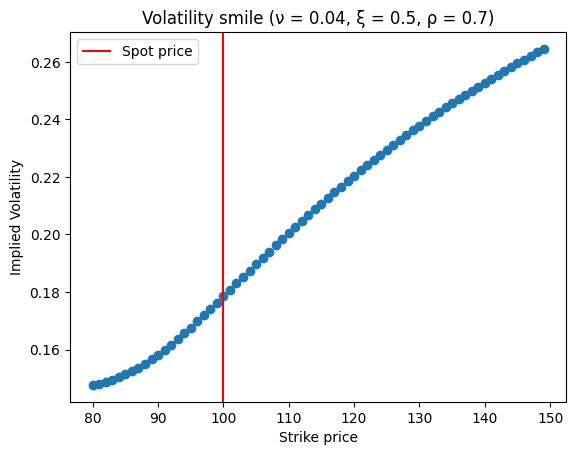

In [83]:
plt.scatter(Ks, IVs)
plt.axvline(S, color="red",label="Spot price")
plt.xlabel("Strike price")
plt.ylabel("Implied Volatility")
plt.legend()
plt.title(f"Volatility smile (ν = {ν0}, ξ = {ξ}, ρ = {ρ})")
plt.savefig("Heston derived smile.png")

In [84]:
# fig, ax = plt.subplots(3, 3, figsize=(12, 12))
# ξs = [0.2, 0.5, 0.]
# for i in range(3):
#     for j in range(3):

In [85]:
def heston(S, T, r, ν0, Θ, κ, ξ, ρ, N, n_sims, K_min, K_max):
    dt = T / N
    
    dWs, dWν = correlated_noise(n_sims, N, ρ, dt)
    
    νs = gen_νs(κ, Θ, ν0, dt, ξ, dWν, N)
    
    Sts = gen_Sts(r, S, dt, νs, dWs, N)
    
    Ks = np.arange(K_min, K_max, 1)
    payoffs = np.maximum(0, Sts[:, -1, np.newaxis] - Ks) * np.exp(-r * T)
    prices = np.mean(payoffs, axis=0)    
    IVs = [imply(K, price) for K, price in zip(Ks, prices)]
    
    return Ks, IVs

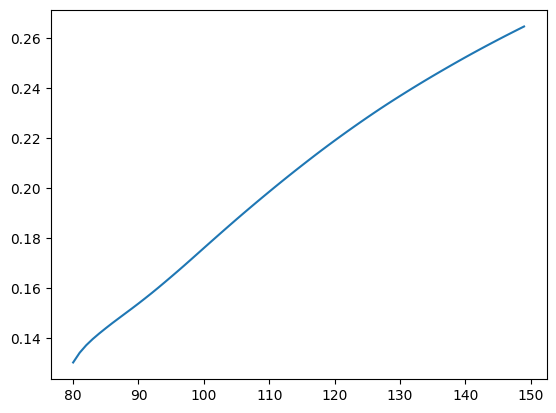

In [86]:
h = heston(S, T, r, ν0, Θ, κ, ξ, ρ, N, n_sims, K_min, K_max)
plt.plot(h[0], h[1]);

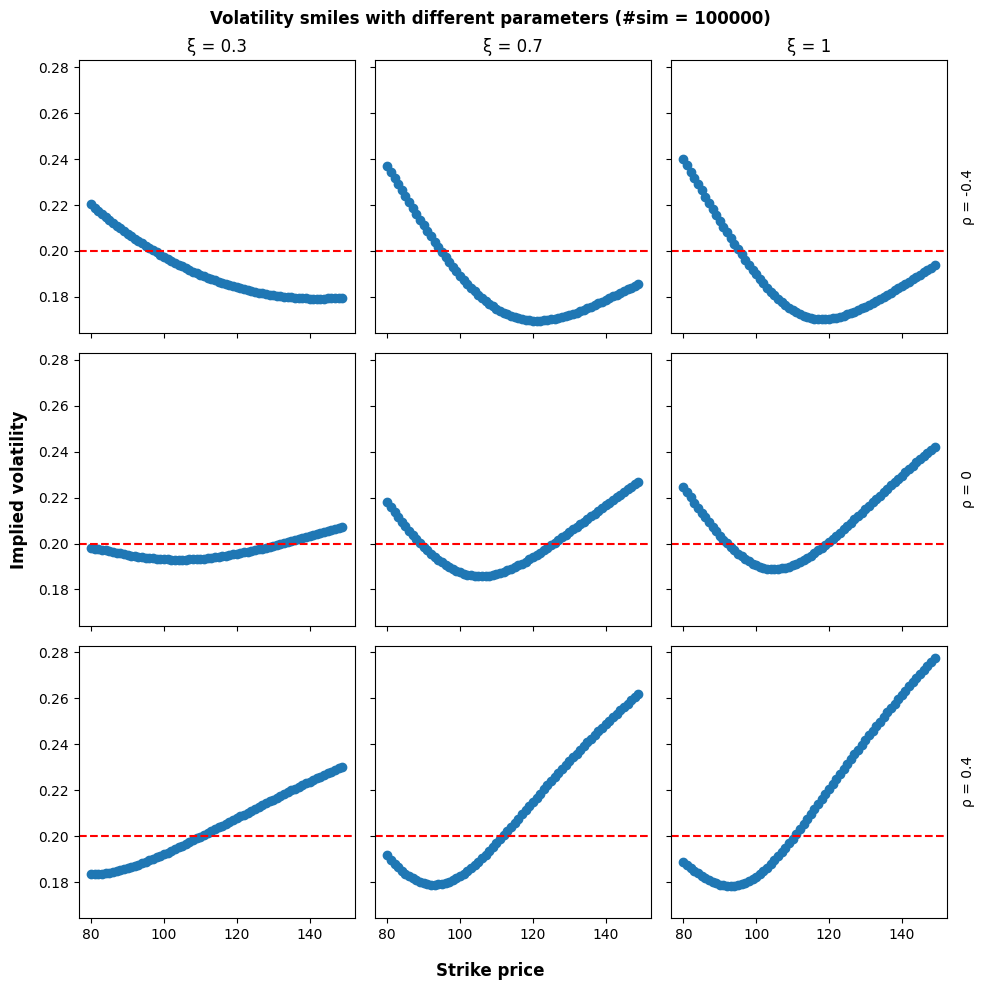

In [87]:
fig, ax = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True)

ξs = [0.3, 0.7, 1]
ρs = [-0.4, 0, 0.4]

for i in range(3):
    for j in range(3):
        Ks, IVs = heston(S, T, r, ν0, Θ, κ, ξs[j], ρs[i], N, n_sims, K_min, K_max)
        ax[i, j].scatter(Ks, IVs)

        ax[i, j].axhline(y=np.sqrt(ν0), linestyle='--', color='red', label='BS (flat)')


for j, ξ_val in enumerate(ξs):
    ax[0, j].set_title(f'ξ = {ξ_val}')

for i, ρ_val in enumerate(ρs):
    ax[i, -1].yaxis.set_label_position('right')

    ax[i, -1].set_ylabel(f'ρ = {ρ_val}', rotation=90, labelpad=10)


fig.supylabel("Implied volatility", fontweight="bold")
fig.supxlabel("Strike price", fontweight="bold")
fig.suptitle(f"Volatility smiles with different parameters (#sim = {n_sims})", fontsize="large", fontweight="bold")
fig.tight_layout()
fig.savefig("Heston smiles.png")